# Previsione dell'abbandono del percorso di studi e del successo da parte di uno studente

Progetto per l'esame di Programmazione di applicazioni Data Intensive (2025/2026)

**Studente**: Vincent Rey Ramos

**Email**: vincentrey.ramos@studio.unibo.it

## Descrizione del Problema
Il dataset qui presente contiene dati raccolti da vari studenti per la previsione sull'abbandono del percorso di studi o alla conseguente laurea.
Il dataset comprende circa 4000 studenti.

L'obbiettivo del progetto è quello di predire una variabile binaria.

## Carimento Librerie

Andiamo a caricare le librerie per effettuare operazioni sui dati:
- Numpy : per creare e operare su array a N dimensioni
- pandas : caricare e manipolare dati tabulari
- matplotlib : per creare grafici

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Caricamento dei dati

Carichiamo ora il dataset su cui ci baseremo ottenuta da [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) , facendo uso della librearia pandas.

In [2]:
import os.path
file_name = "./dataset.csv"

if not os.path.exists(file_name):
    print("Missing dataset , retrieve it from kaggle")

raw_data = pd.read_csv(file_name)

In [3]:
raw_data.info(verbose = False , memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Columns: 35 entries, Marital status to Target
dtypes: float64(5), int64(29), str(1)
memory usage: 1.4 MB


In [4]:
raw_data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
pd.set_option('display.max_columns' , None)
raw_data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,7.819168,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,4.856692,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,46.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Il dataset contiene queste entry:

#### Informazioni Personali e Sociali
* **Marital status**: Stato civile. (Categorica)
* **Nacionality**: Nazionalità. (Categorica)
* **Displaced**: Studente fuori sede. (Categorica)
* **Gender**: Genere. (Categorica)
* **Age at enrollment**: Età all'iscrizione. (Numerica)
* **International**: Studente internazionale. (Categorica)

#### Background Familiare
* **Mother's qualification**: Qualifica della madre. (Categorica)
* **Father's qualification**: Qualifica del padre. (Categorica)
* **Mother's occupation**: Occupazione della madre. (Categorica)
* **Father's occupation**: Occupazione del padre. (Categorica)

#### Percorso Accademico e Iscrizione
* **Application mode**: Modalità di domanda. (Categorica)
* **Application order**: Ordine di preferenza della domanda. (Numerica)
* **Course**: Corso di studi scelto. (Categorica)
* **Daytime/evening attendance**: Frequenza diurna o serale. (Categorica)
* **Previous qualification**: Qualifica precedente. (Categorica)

#### Situazione Economica e Bisogni
* **Educational special needs**: Bisogni educativi speciali. (Categorica)
* **Debtor**: Studente debitore. (Categorica)
* **Tuition fees up to date**: Tasse in regola. (Categorica)
* **Scholarship holder**: Borsista. (Categorica)

#### Rendimento 1° Semestre
* **Curricular units 1st sem (credited)**: Unità accreditate. (Numerica)
* **Curricular units 1st sem (enrolled)**: Unità iscritte. (Numerica)
* **Curricular units 1st sem (evaluations)**: Valutazioni effettuate. (Numerica)
* **Curricular units 1st sem (approved)**: Unità superate. (Numerica)
* **Curricular units 1st sem (grade)**: Media voti. (Numerica)
* **Curricular units 1st sem (without evaluations)**: Unità senza valutazione. (Numerica)

#### Rendimento 2° Semestre
* **Curricular units 2nd sem (credited)**: Unità accreditate. (Numerica)
* **Curricular units 2nd sem (enrolled)**: Unità iscritte. (Numerica)
* **Curricular units 2nd sem (evaluations)**: Valutazioni effettuate. (Numerica)
* **Curricular units 2nd sem (approved)**: Unità superate. (Numerica)
* **Curricular units 2nd sem (grade)**: Media voti. (Numerica)
* **Curricular units 2nd sem (without evaluations)**: Unità senza valutazione. (Numerica)

#### Indicatori Macroeconomici
* **Unemployment rate**: Tasso di disoccupazione nazionale. (Numerica)
* **Inflation rate**: Tasso di inflazione nazionale. (Numerica)
* **GDP**: PIL nazionale. (Numerica)

#### Obiettivo (Target)
* **Target**: Esito finale dello studente (Dropout, Enrolled, Graduate). (Categorica)

In [6]:
raw_data.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

Da come si può vedere non sono presenti valori nulla nel dataset , dunque non è necessario pulirlo da vari valori nulli.

In [7]:
raw_data["Target"].head(20)

0      Dropout
1     Graduate
2      Dropout
3     Graduate
4     Graduate
5     Graduate
6     Graduate
7      Dropout
8     Graduate
9      Dropout
10    Graduate
11    Graduate
12     Dropout
13    Graduate
14    Graduate
15     Dropout
16    Enrolled
17    Graduate
18    Graduate
19    Enrolled
Name: Target, dtype: str

## Trasformazione dei dati
L'obbiettivo specificato all'inizio è di prevedere se uno studente sia un dropout oppure graduate , dunque modificheremo i dati in modo da ignorare tutte le entry con valore "Enrolled" e settare i valori dei restanti a binari.In conclusione , "Dropout" avrà valore 0 e "Graduate" avrà valore 1.

In [8]:
trasformed_data = raw_data[raw_data["Target"] != "Enrolled"]
trasformed_data['Target'] = trasformed_data['Target'].map({'Dropout' : 0 ,  'Graduate' : 1})
trasformed_data.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1


Trasformo anche la colonna "Nacionality" in "Nationality" per mantenere la lingua inglese.

In [9]:
trasformed_data = trasformed_data.rename(columns={'Nacionality': 'Nationality'})

In [10]:
trasformed_data.info(verbose=False , memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Columns: 35 entries, Marital status to Target
dtypes: float64(5), int64(30)
memory usage: 1020.9 KB


## Esplorazione dei Dati
In questa fase analizzeremo la struttura dei dati e la loro distribuzione, in modo da capire come prepararli.

In [11]:
trasformed_data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.184298,6.810193,1.750138,9.935537,0.887603,2.552617,1.242424,12.558678,16.663636,7.212948,7.650138,0.549036,0.011019,0.113774,0.866116,0.344077,0.266942,23.461157,0.023691,0.754270,6.337466,8.071074,4.791460,10.534860,0.128926,0.581818,6.296419,7.763085,4.518457,10.036155,0.142149,11.630358,1.231598,-0.009256,0.608540
std,0.613009,5.253618,1.333831,4.340715,0.315897,3.952440,1.700394,9.006183,10.993025,3.707343,4.315144,0.497658,0.104407,0.317580,0.340575,0.475132,0.442423,7.827994,0.152107,2.477277,2.570773,4.286632,3.237845,5.057694,0.679111,2.022688,2.263020,3.964163,3.162376,5.481742,0.747670,2.667652,1.384911,2.259986,0.488144
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.517857,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,8.000000,1.000000,11.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.341429,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000,1.000000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000,1.000000
max,6.000000,18.000000,6.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,46.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000


Dai dati si può notare che per circa i tre quinti delle righe sono labeled come 'Graduated'.Questo potrebbe comportare un problema nella fase di addestramento del modello , dato che potrebbe favorire una classe rispetto che ad un'altra.

Qui si può visualizzare le percentuali tramite diagramma a torta.

Target
1    2209
0    1421
Name: count, dtype: int64


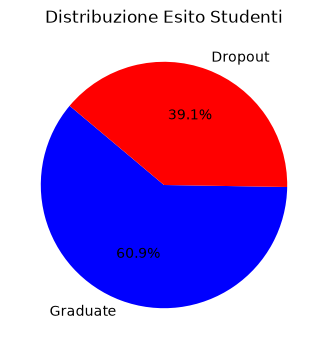

In [12]:
counts = trasformed_data['Target'].value_counts()

labels = ['Graduate', 'Dropout']

print(trasformed_data['Target'].value_counts())

plt.figure(figsize=(4,4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['blue','red'])
plt.title('Distribuzione Esito Studenti')
plt.show()

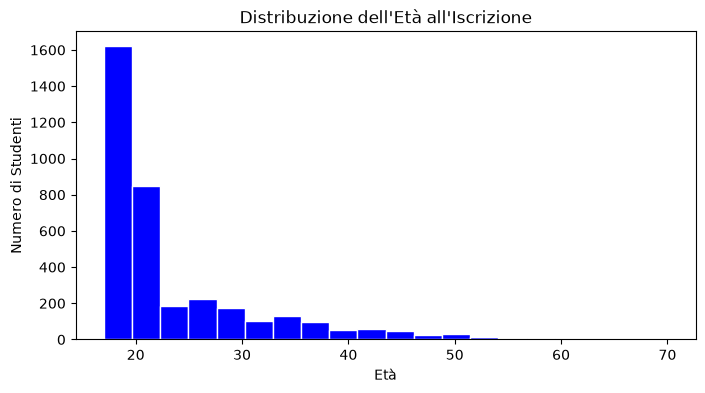

In [13]:
plt.figure(figsize=(8,4))
plt.hist(trasformed_data['Age at enrollment'], bins=20, color='blue', edgecolor='white')
plt.title('Distribuzione dell\'Età all\'Iscrizione')
plt.xlabel('Età')
plt.ylabel('Numero di Studenti')
plt.show()

Dai dati possiamo anche notare che la maggior parte degli studenti hanno età compresa tra i 17(minimo ricavato dai dati) e i 23 (la media)

In [14]:
def genera_istogrammi(colonne, titoli, titolo_principale, colore):
    plt.figure(figsize=(18, 12))
    plt.suptitle(titolo_principale, fontsize=20)
    
    for i in range(len(colonne)):
        plt.subplot(3, 2, i + 1)
        plt.hist(trasformed_data[colonne[i]], bins=20, color=colore, edgecolor='black')
        plt.title(titoli[i])
        plt.ylabel('Numero di Studenti')
        plt.xlabel('Valore')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

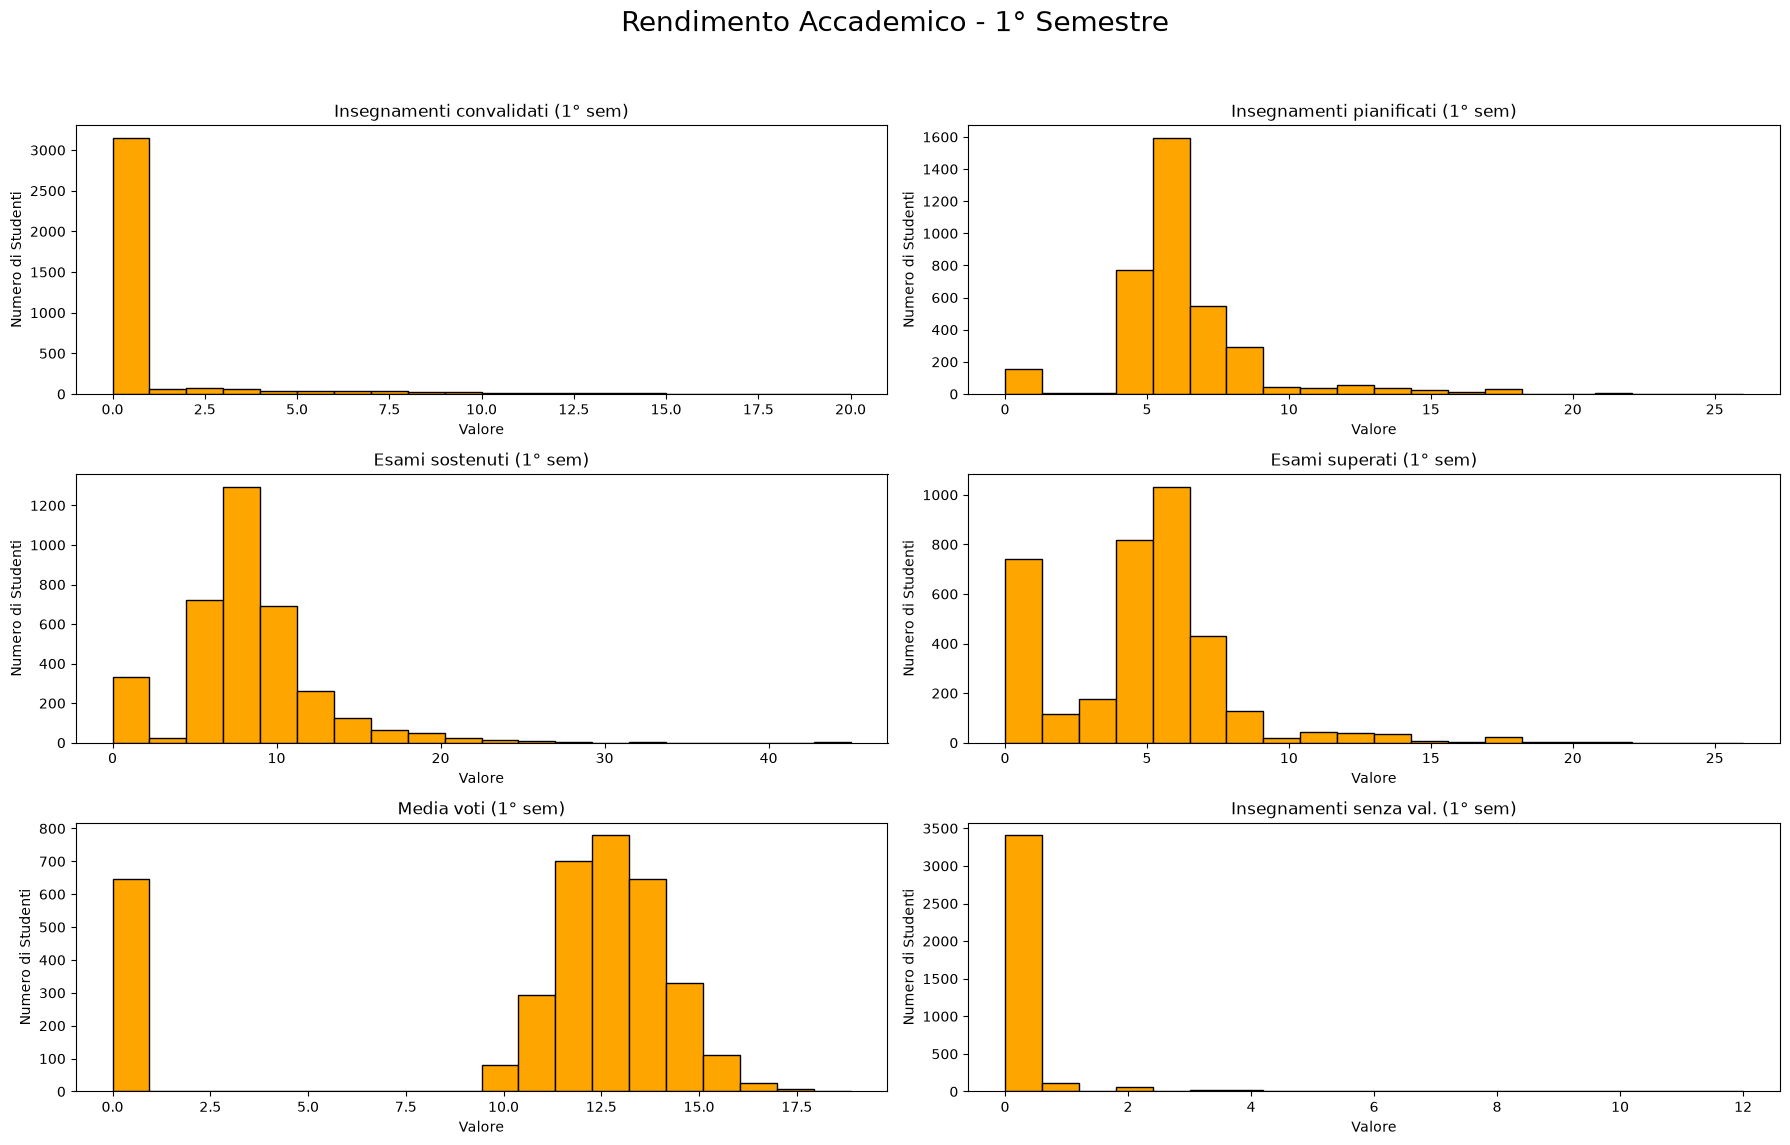

In [15]:
insegnamenti_1sem = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)'
]

titoli_1sem = [
    'Insegnamenti convalidati (1° sem)', 'Insegnamenti pianificati (1° sem)',
    'Esami sostenuti (1° sem)', 'Esami superati (1° sem)',
    'Media voti (1° sem)', 'Insegnamenti senza val. (1° sem)'
]
genera_istogrammi(insegnamenti_1sem, titoli_1sem, 'Rendimento Accademico - 1° Semestre', 'orange')

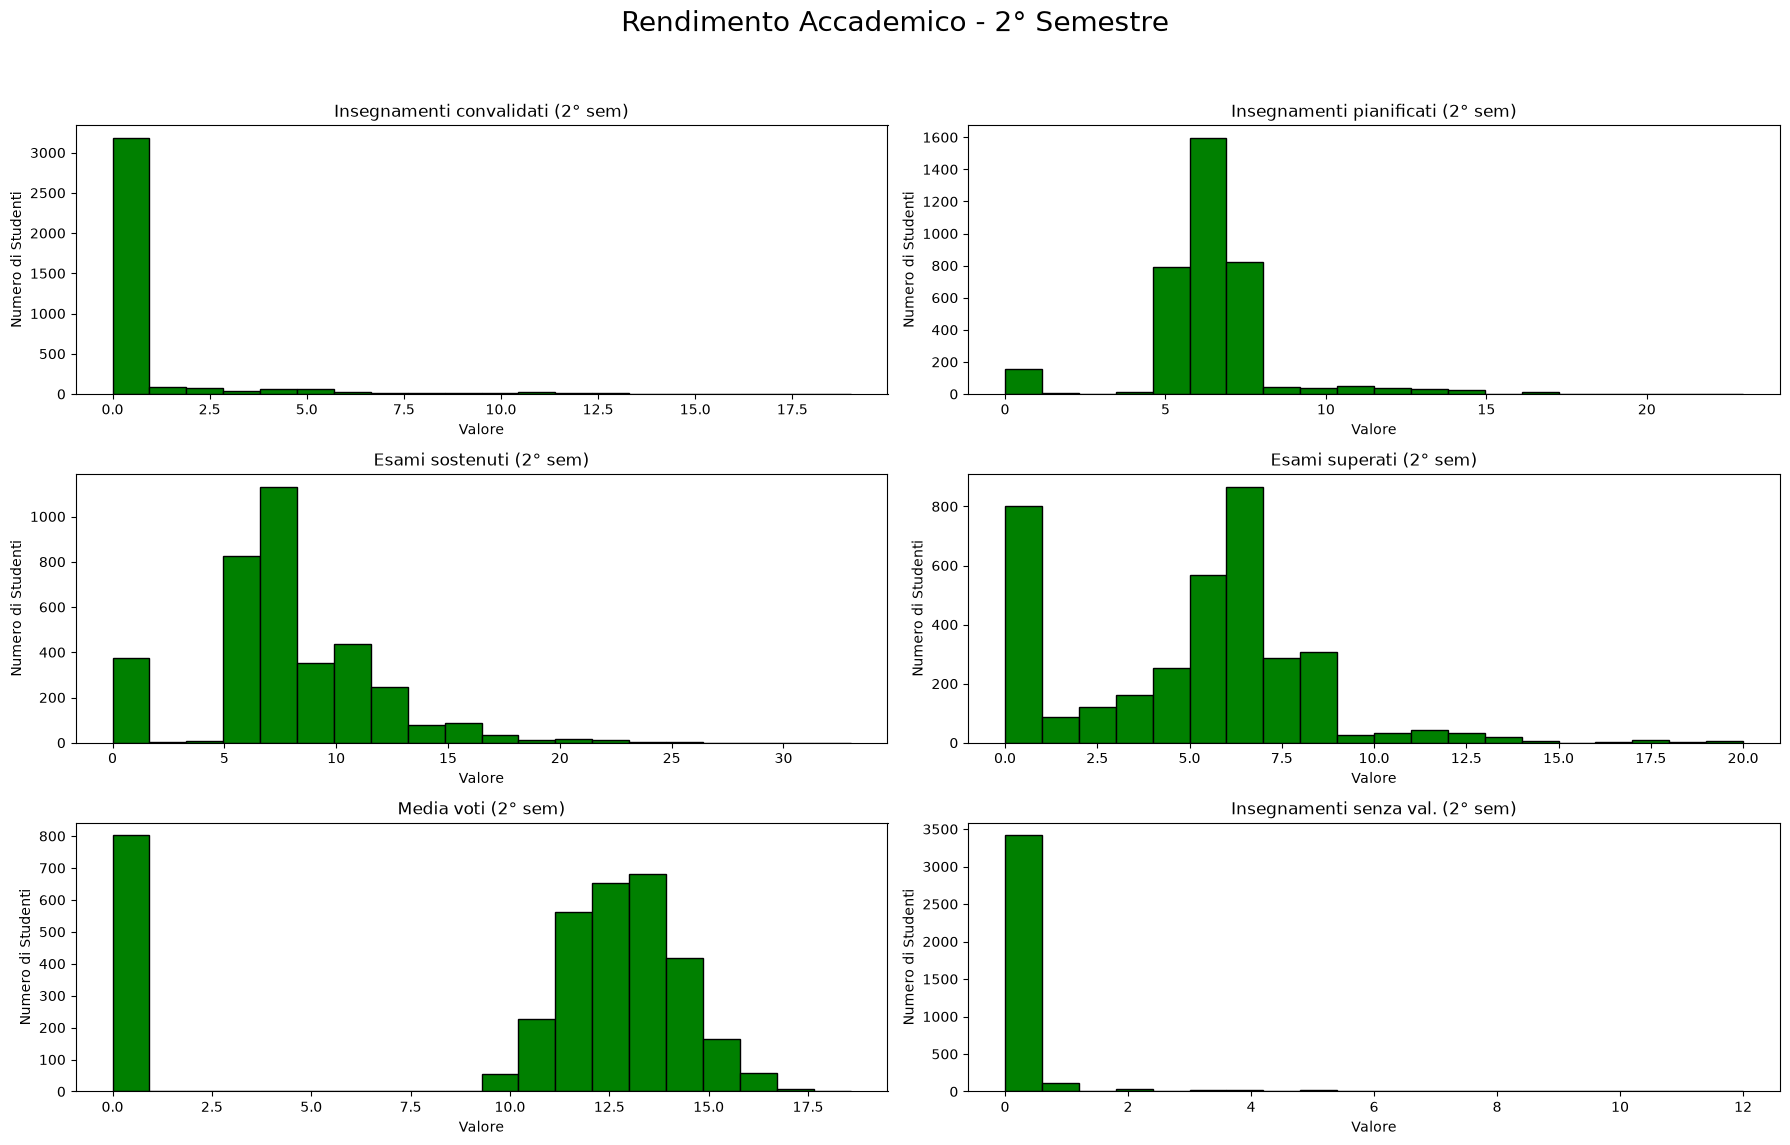

In [16]:
insegnamenti_2sem = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]

titoli_2sem = [
    'Insegnamenti convalidati (2° sem)', 'Insegnamenti pianificati (2° sem)',
    'Esami sostenuti (2° sem)', 'Esami superati (2° sem)',
    'Media voti (2° sem)', 'Insegnamenti senza val. (2° sem)'
]

genera_istogrammi(insegnamenti_2sem, titoli_2sem, 'Rendimento Accademico - 2° Semestre', 'green')

### Confronto tra Semestri
Confrontando visivamente i due blocchi di grafici (arancione per il 1° semestre e verde per il 2°), la struttura delle distribuzioni rimane simile. Tuttavia, il numero di studenti che presentano zero esami superati nel secondo semestre è un indicatore critico: se tale numero aumenta rispetto al primo semestre, il modello di predizione lo interpreterà probabilmente come un segnale decisivo di imminente abbandono degli studi.  

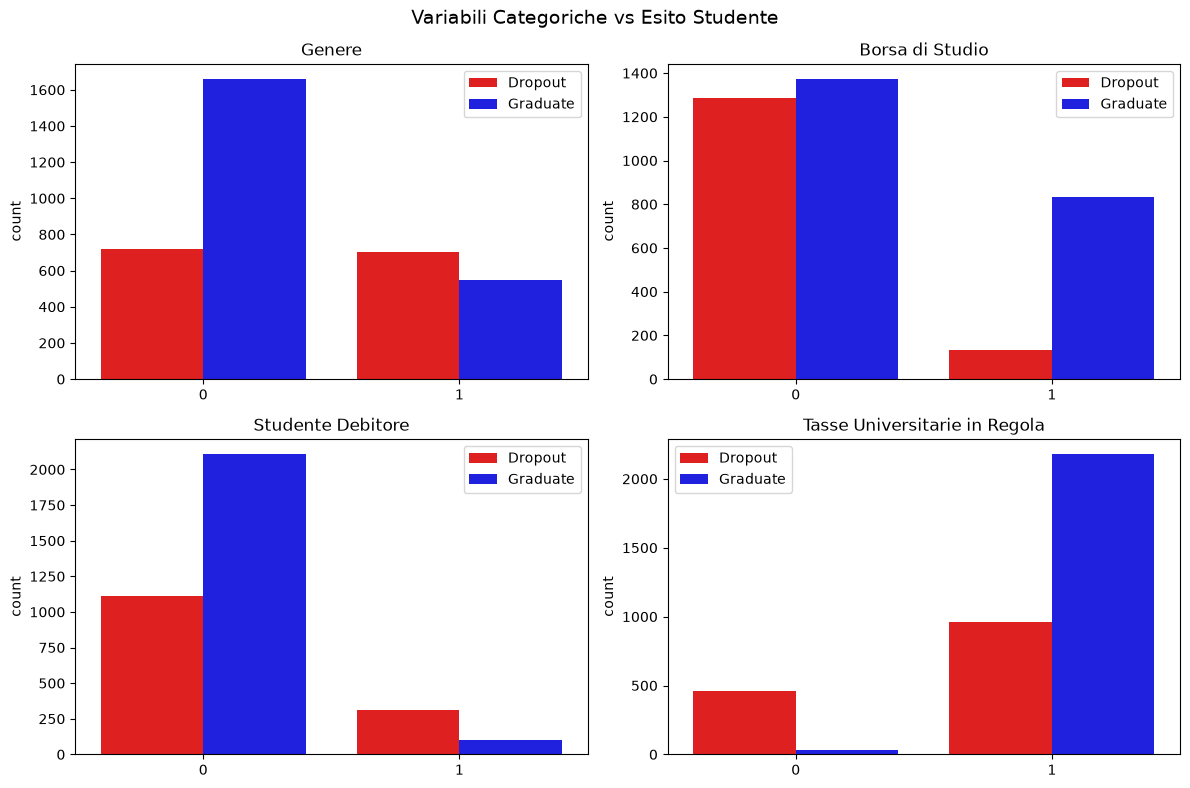

In [17]:
cat_cols = ['Gender', 'Scholarship holder', 'Debtor', 'Tuition fees up to date']
titoli = ['Genere', 'Borsa di Studio', 'Studente Debitore', 'Tasse Universitarie in Regola']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Target', data=trasformed_data,
                  ax=axes[i], palette={0: 'red', 1: 'blue'})
    axes[i].set_title(titoli[i])
    axes[i].legend(['Dropout', 'Graduate'])
    axes[i].set_xlabel('')

plt.suptitle('Variabili Categoriche vs Esito Studente', fontsize=14)
plt.tight_layout()
plt.show()

Da questo grafico invece possiamo notare varie correlazioni fra i dati:
- Chi di solito è in regola con le tasse universitarie tende molto fortemente a laurearsi.
- Chi invece è debitore , quindi non con tasse universitarie in regola , tende invece ad abbandonare il percorso di studi.
- La maggior parte degli studenti che possiedono la borsa di studio tendono a completare il percorso di studi.

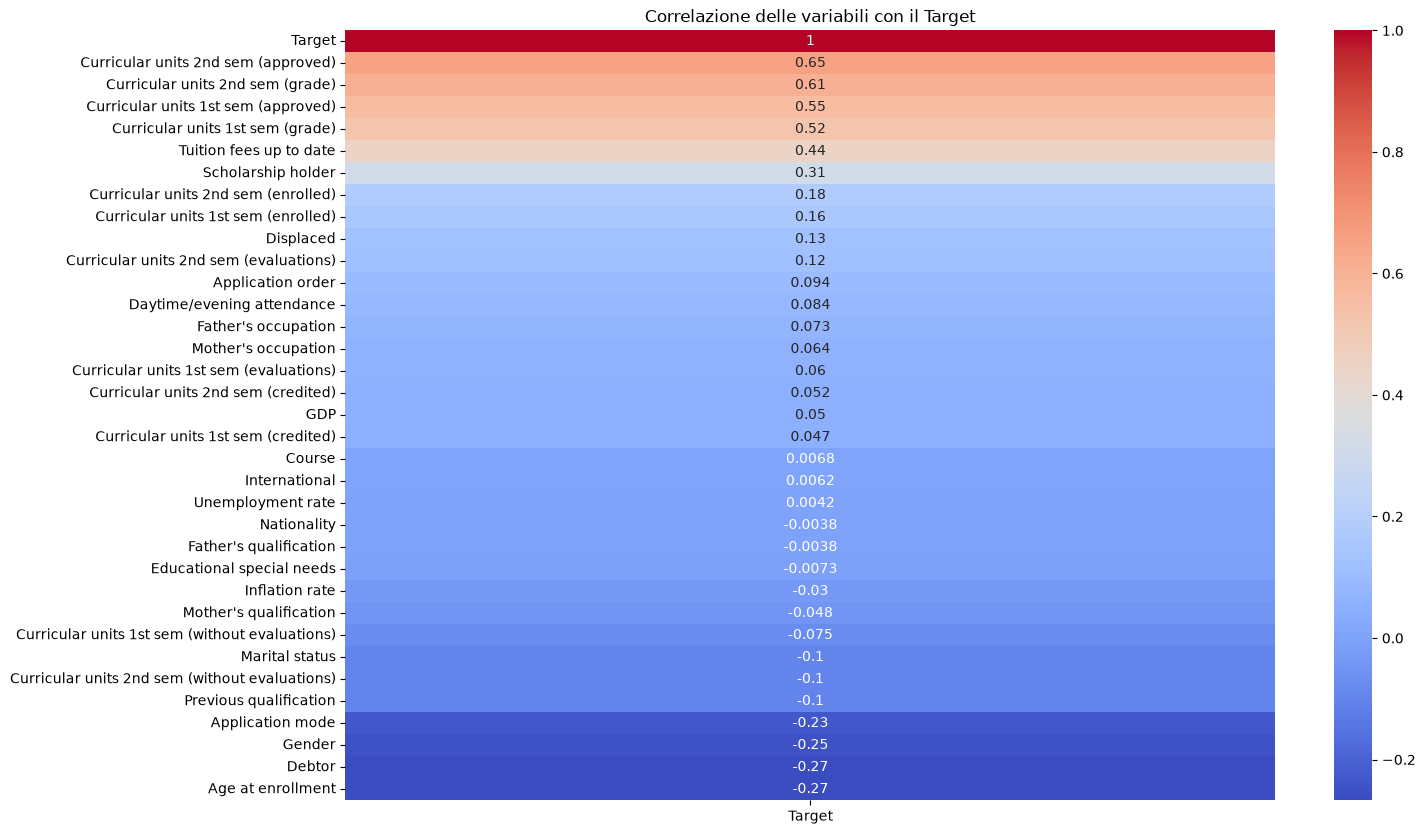

In [18]:
plt.figure(figsize=(15, 10))

corr = trasformed_data.corr()

sns.heatmap(corr[['Target']].sort_values(by='Target', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlazione delle variabili con il Target")
plt.show()


Dall'analisi fra la correlazione dei dati si può vedere che i dati più influenti con la variabile target sono:

- **Curricular units 1st/2nd sem (approved) (0.55 / 0.65)**: il numero di esami superati in entrambi i semestri è il predittore più forte chi supera più esami tende fortemente a laurearsi

- **Curricular units 1st/2nd sem (grade) (0.52 / 0.61)**: la media dei voti segue lo stesso pattern, confermando che rendimento
accademico e completamento del percorso sono strettamente legati

- **Tuition fees up to date (0.44)**: essere in regola con le tasse universitarie è il terzo predittore più forte, coerente con quanto
già osservato nel countplot precedente

- **Scholarship holder (0.31)**: avere una borsa di studio ha una correlazione positiva moderata con la laurea

Mentre quelle con correlazione negativa più rilevante sono:

- **Age at enrollment (-0.27)**: gli studenti più anziani all'iscrizione tendono più al dropout, probabilmente per impegni lavorativi o familiari

- **Debtor (-0.27)**: essere debitore è un segnale di rischio abbandono, legato anche alla variabile precedente sulle tasse

- **Gender (-0.25)**: c'è una leggera correlazione negativa, da interpretare con cautela dato che non è un fattore causale

Le variabili con correlazione prossima a zero (come Nationality, International, Educational special needs, Unemployment rate) verranno rimosse nella fase di preprocessing in quanto poco informative per il modello.

## Lavorazione dei dati

Andiamo a togliere i dati poco informativi visti in precedenza tramite la matrice di correlazione.

In [19]:
cols_to_drop = ['Inflation rate' , 'Unemployment rate' , "Mother's qualification" , 'Nationality' , 
               "Father's qualification" , 'Educational special needs' , 'International' , 'Course']
df = trasformed_data.drop(cols_to_drop , axis=1).copy()
df.head()

,Marital status,Application mode,Application order,Daytime/evening attendance,Previous qualification,Mother's occupation,Father's occupation,Displaced,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),GDP,Target
0,1,8,5,1,1,6,10,1,0,1,1,0,20,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,1.74,0
1,1,6,1,1,1,4,4,1,0,0,1,0,19,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,0.79,1
2,1,1,5,1,1,10,10,1,0,0,1,0,19,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,1.74,0
3,1,8,2,1,1,6,4,1,0,1,0,0,20,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,-3.12,1
4,2,12,1,0,1,10,10,0,0,1,0,0,45,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,0.79,1


Per la varibile marital_status vado a suddividere i vari valori con i loro nomi, rendendole ognuno come variabili binarie.

In [20]:
marital_status_map = {
    1: 'single',
    2: 'married',
    3: 'widower',
    4: 'divorced',
    5: 'facto union',
    6: 'legally separated'
}

df['Marital status'] = df['Marital status'].map(marital_status_map)

df = pd.get_dummies(df, columns=['Marital status'], dtype=int)

df.head()

,Application mode,Application order,Daytime/evening attendance,Previous qualification,Mother's occupation,Father's occupation,Displaced,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),GDP,Target,Marital status_divorced,Marital status_facto union,Marital status_legally separated,Marital status_married,Marital status_single,Marital status_widower
0,8,5,1,1,6,10,1,0,1,1,0,20,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,1.74,0,0,0,0,0,1,0
1,6,1,1,1,4,4,1,0,0,1,0,19,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,0.79,1,0,0,0,0,1,0
2,1,5,1,1,10,10,1,0,0,1,0,19,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,1.74,0,0,0,0,0,1,0
3,8,2,1,1,6,4,1,0,1,0,0,20,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,-3.12,1,0,0,0,0,1,0
4,12,1,0,1,10,10,0,0,1,0,0,45,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,0.79,1,0,0,0,1,0,0


Suddividiamo ora i dati nelle due variabili X e Y.

In [21]:
X = df.drop('Target', axis = 1)
y = df['Target']

print("Variabili predittive (X):", X.shape)
print("Variabile target (y):", y.shape)


Variabili predittive (X): (3630, 31)
Variabile target (y): (3630,)


Andiamo ora a dividere a dividere il set in training e test set , seguendo una suddivisione 70/30.

In [22]:
from sklearn.model_selection import train_test_split

X_train , X_val , y_train , y_val = train_test_split(X, y, test_size=0.3 , random_state = 42 , stratify=y)

print("\nTraining set:", X_train.shape)
print("Test set:", X_val.shape)


Training set: (2541, 31)
Test set: (1089, 31)


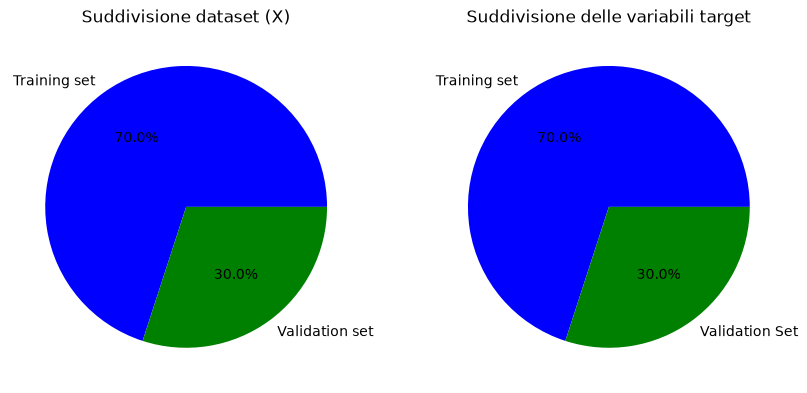

In [23]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)

sizes_X = [len(X_train), len(X_val)]

plt.pie(sizes_X, labels=['Training set', 'Validation set'], colors=["Blue","Green"], autopct="%1.1f%%")
plt.title('Suddivisione dataset (X)')

size_y = [len(y_train) , len(y_val)]
plt.subplot(1,2,2)
plt.pie(size_y,labels=['Training set','Validation Set'] ,colors=["Blue","Green"], autopct="%1.1f%%")
plt.title('Suddivisione delle variabili target')
plt.show()

Dato che in precedenza sapevamo che avevamo circa il 60% di "Graduate" e 40% di "Dropout" , pur essendo poco bilanciato ma accettabile , rendiamo equo il dataset in modo che questi sia una percentuale equa. Utilizzeremo dunque lo SMOTE per bilanciare la classe minoritaria.

## Addestramento e Analisi dei Modelli

Importiamo tutte le funzioni di librerie di supporto che ci serviranno.

In [24]:
from imblearn.pipeline import Pipeline     
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

Creiamo funzioni a sostegno della nostra analisi dei vari modelli di classificazione che andremo ad usare:
- Una funzione per mostrare tutte le metriche
- Una per far vedere la matrice di confusione
- Una per vedere i dati significativi per i vari modelli

Vengono usati:

- **StandardScaler**: per normalizzare tutte le variabili sulla stessa scala, operazione necessaria soprattutto per Perceptron e SVC che sono sensibili alla scala degli input.
- **SMOTE**: applicato sul training set per bilanciare le classi, portando la distribuzione Dropout/Graduate a 50/50 invece del ~40/60 osservato nei dati originali.

In [25]:
def print_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- Risultati per: {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print("-" * 35)

In [26]:
def show_confusion_matrix(model_name, y_val, y_pred_model):
    cm = confusion_matrix(y_val, y_pred_model)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout','Graduate'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [27]:
def show_feature_importances(model_name, pipeline):
    model = pipeline['model']
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = model.coef_[0]
    else:
        print(f"Attenzione: Impossibile estrarre l'importanza per {model_name}.")
        return

    # 3. Creiamo la Serie per il grafico usando X.columns
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    
    # 4. Disegniamo il grafico
    plt.figure(figsize=(9, 7))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance — {model_name}')
    plt.xlabel('Importanza')
    plt.tight_layout()
    plt.show()

### Perceptron

In [28]:
from sklearn.linear_model import Perceptron

base_perceptron = Pipeline([
    ('scale', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', Perceptron(max_iter=1000, random_state=42))
])

base_perceptron.fit(X_train, y_train)

y_pred_perceptron = base_perceptron.predict(X_val)

print_metrics('Perceptron', y_val, y_pred_perceptron)

--- Risultati per: Perceptron ---
Accuracy  : 0.8843
Precision : 0.9202
Recall    : 0.8869
F1 Score  : 0.9032
-----------------------------------


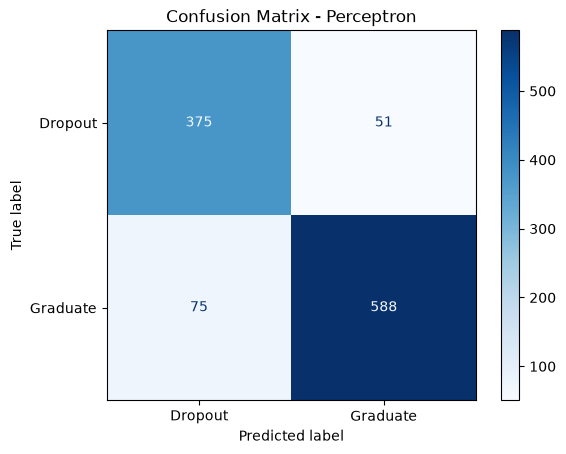

In [29]:
show_confusion_matrix('Perceptron', y_val, y_pred_perceptron)

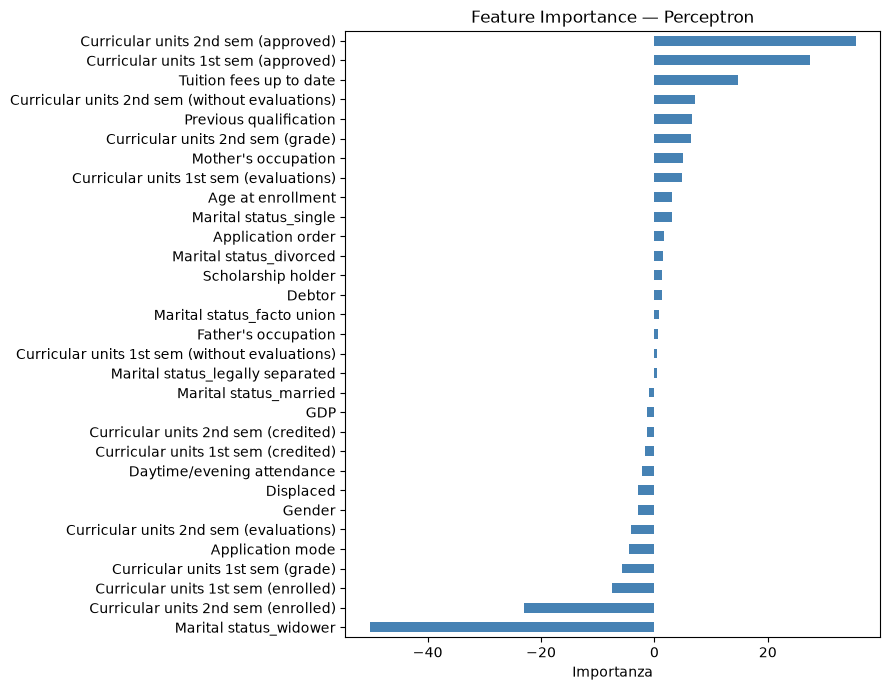

In [30]:
show_feature_importances('Perceptron', base_perceptron)

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:

- **350**: Dropout classificati correttamente
- **598**: Graduate classificati correttamente
- **65**: Falsi positivi (classificati come Graduate ma sono Dropout)
- **76**: Falsi negativi (classificati come Dropout ma sono Graduate)

Dal grafico delle feature importance, Curricular units 2nd sem (approved) domina nettamente rispetto a tutte le altre variabili, confermando quanto già visto nell'heatmap e nel plot dell'albero: il rendimento accademico nel secondo semestre è il predittore più determinante per distinguere dropout da laureati.

### SVM

In [48]:
from sklearn.svm import SVC

base_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(kernel='linear', random_state=42))
])

base_svm.fit(X_train, y_train)

y_pred_svm = base_svm.predict(X_val)

print_metrics('SVC', y_val, y_pred_svm)

--- Risultati per: SVC ---
Accuracy  : 0.8962
Precision : 0.9142
Recall    : 0.9155
F1 Score  : 0.9148
-----------------------------------


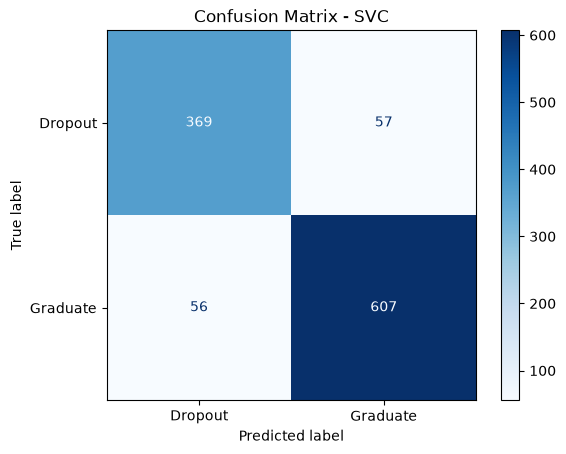

In [49]:
show_confusion_matrix('SVC', y_val, y_pred_svm)

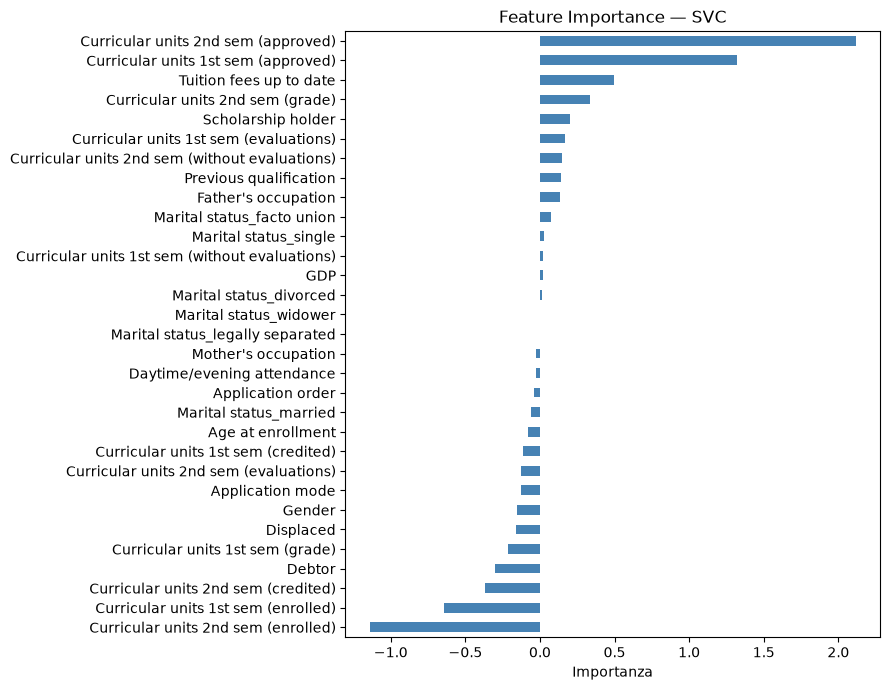

In [50]:
show_feature_importances('SVC', base_svm)

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:

- **369**: Dropout classificati correttamente
- **607**: Graduate classificati correttamente
- **57**: Falsi positivi (classificati come Graduate ma sono Dropout)
- **56**: Falsi negativi (classificati come Dropout ma sono Graduate)

Si nota come il modello SVC migliori di gran lunga le predizioni rispetto al modello del Perceptron, riducendo sia i falsi positivi (da 76 a 57) che i falsi negativi (da 65 a 56). La Precision (0.9142) e il Recall (0.9155) sono quasi identiche, segno che SVC bilancia molto bene i due tipi di errore.
Dal grafico delle feature importance (coefficienti del kernel lineare), il pattern è coerente con quanto visto nell'heatmap e nel Perceptron:

- **Curricular units 2nd/1st sem (approved)** dominano con i coefficienti positivi più alti (2.1 e 1.35), confermando che superare esami è il segnale più forte verso la laurea
- **Tuition fees up to date e Curricular units 2nd sem (grade)** seguono con coefficienti positivi rilevanti
- **Curricular units 2nd/1st sem (enrolled)** mostrano i coefficienti negativi più marcati (-1.0 e -0.5) — avere molti esami pianificati ma pochi superati è un segnale di rischio dropout

### Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

base_decision_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

base_decision_tree.fit(X_train, y_train)

y_pred_tree = base_decision_tree.predict(X_val)

print_metrics('Decision Tree', y_val, y_pred_tree)

--- Risultati per: Decision Tree ---
Accuracy  : 0.8705
Precision : 0.8872
Recall    : 0.9020
F1 Score  : 0.8945
-----------------------------------


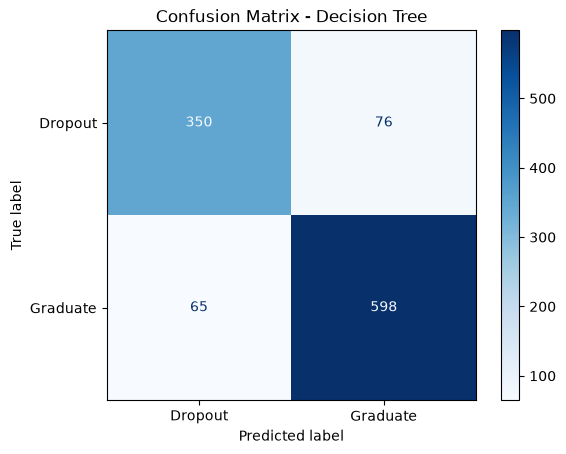

In [35]:
show_confusion_matrix('Decision Tree', y_val, y_pred_tree)

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:

- **350**: Dropout classificati correttamente
- **598**: Graduate classificati correttamente
- **65**: Falsi positivi (classificati come Graduate ma sono Dropout)
- **76**: Falsi negativi (classificati come Dropout ma sono Graduate)

Il Decision Tree è il modello con le performance più basse tra i quattro (Accuracy 0.8705, F1 0.8945), con più falsi negativi rispetto all'SVC (76 vs 56) — ovvero più studenti a rischio dropout non identificati.
Dal grafico delle feature importance emerge un pattern più "concentrato" rispetto agli altri modelli: 
- **Curricular units 2nd sem (approved)** domina in modo schiacciante, con un'importanza nettamente superiore a tutte le altre variabili.
- Le feature successive (Tuition fees up to date, **Curricular units 2nd sem (enrolled, grade)** contribuiscono in modo molto più marginale.

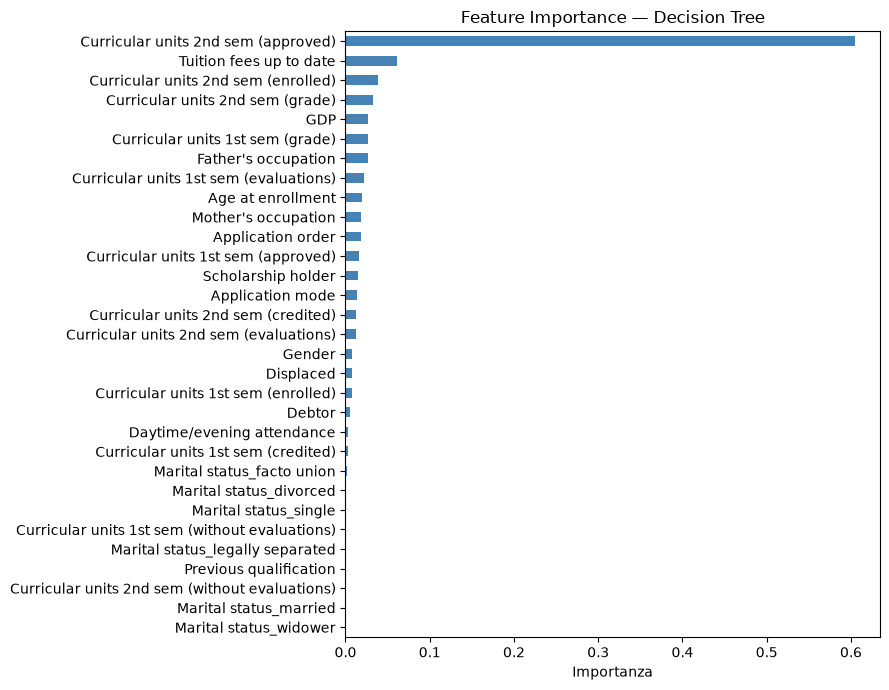

In [36]:
show_feature_importances('Decision Tree', base_decision_tree)

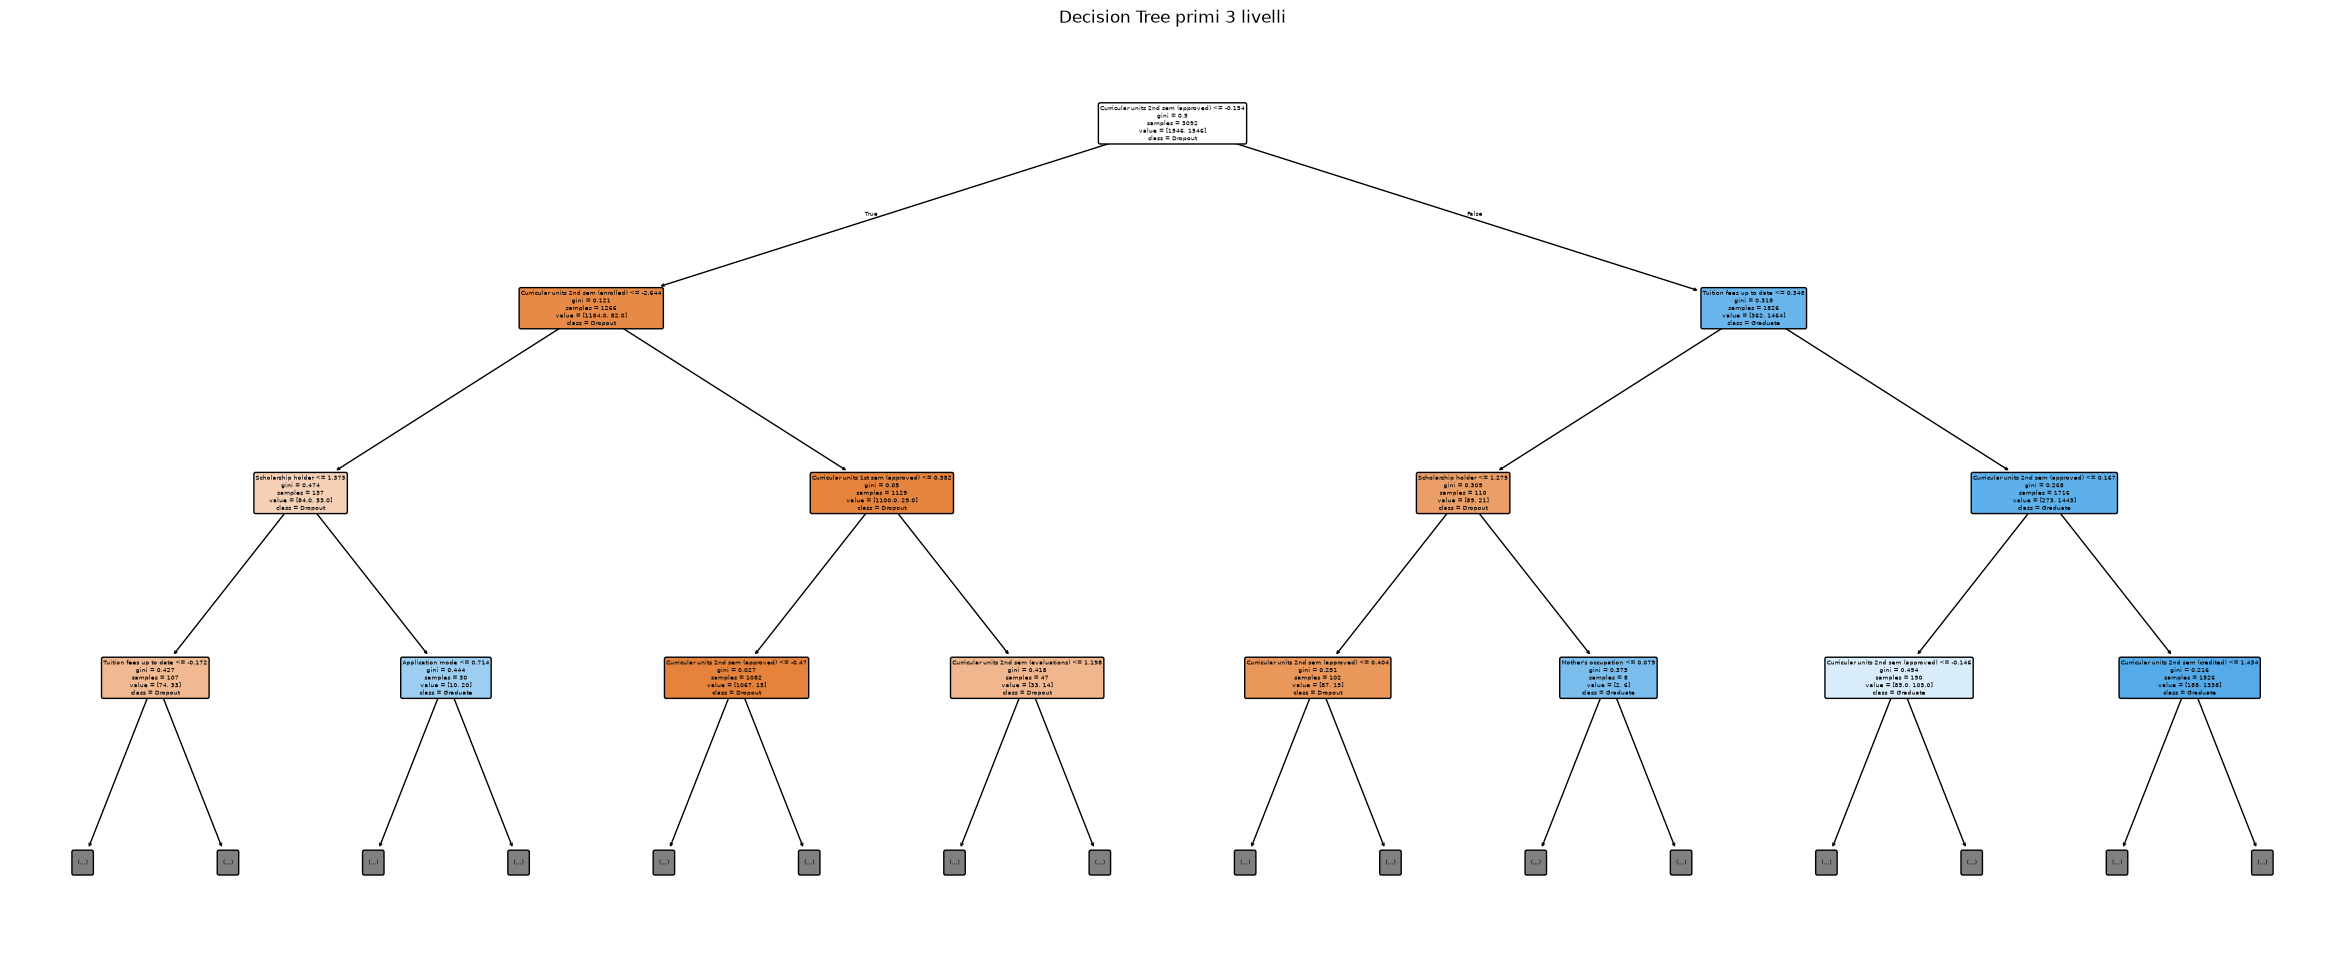

In [37]:
plt.figure(figsize=(30,12))
plot_tree(base_decision_tree['model'], max_depth=3, feature_names=X.columns,
          class_names=['Dropout', 'Graduate'],
          filled=True, rounded=True)
plt.title('Decision Tree primi 3 livelli')
plt.show()

L'albero conferma quanto già emerso dall'analisi di correlazione: il nodo radice divide gli studenti in base a "Curricular units 2nd sem (approved)" (≤ -0.154), la variabile più informativa in assoluto — chi ha pochi esami superati nel secondo semestre tende fortemente al dropout (ramo sinistro, classe maggioritaria "Dropout"), mentre chi ne ha di più tende alla laurea (ramo destro, classe maggioritaria "Graduate").
Negli split successivi emergono altre variabili coerenti:

- "Tuition fees up to date": chi non è in regola con le tasse universitarie viene smistato verso il dropout, confermando la forte correlazione vista nel countplot iniziale.
"Scholarship holder": avere una borsa di studio sembra associarsi a maggiore probabilità di laurea, probabilmente perché riflette anche un certo livello di merito accademico pregresso.
- "Curricular units 1st sem (approved)": anche il rendimento nel primo semestre è un buon predittore, segno che le difficoltà accademiche tendono a manifestarsi presto e a persistere nei semestri successivi.

Il fatto che la stessa variabile ("Curricular units ... (approved)") ricompaia a più livelli dell'albero rafforza l'idea che il rendimento accademico nei primi semestri sia il fattore predittivo dominante per l'abbandono degli studi, più di variabili socio-demografiche come genere o nazionalità.

### XGBoost

In [38]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)

print_metrics('XGBoost', y_val, y_pred_xgb)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
--- Risultati per: XGBoost ---
Accuracy  : 0.9073
Precision : 0.9003
Recall    : 0.9532
F1 Score  : 0.9260
-----------------------------------


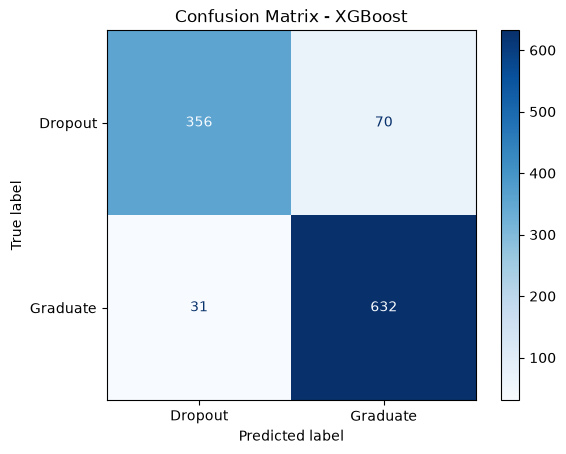

In [39]:
show_confusion_matrix('XGBoost', y_val, y_pred_xgb)

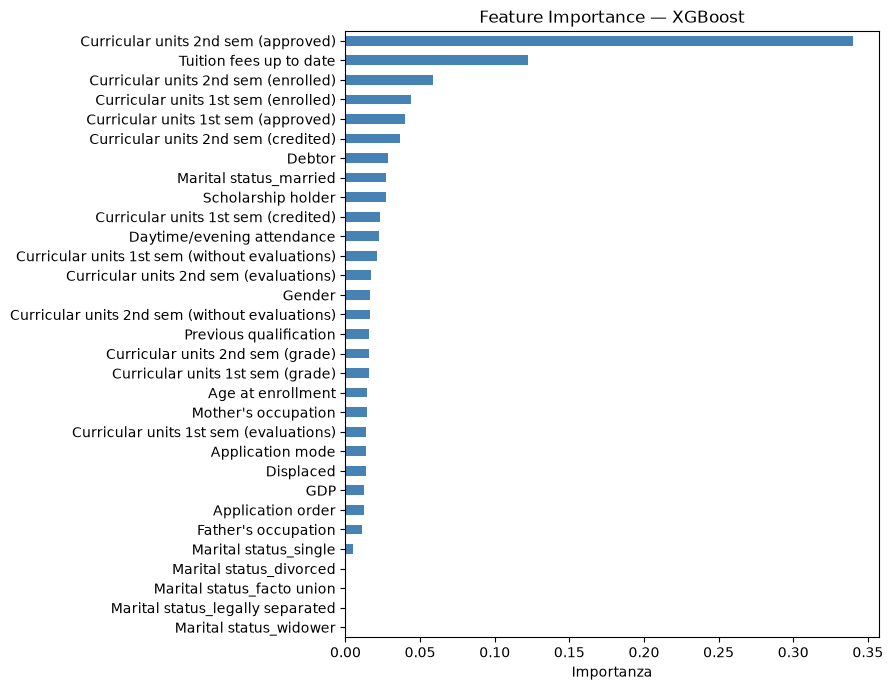

In [40]:
show_feature_importances('XGBoost' , xgb_model)

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:
- **356** Dropout classificati correttamente
- **632** Graduate classificati correttamente
- **70** Falsi positivi (classificati come Graduate ma sono Dropout)
- **31** Falsi negativi (classificati come Dropout ma sono Graduate)

XGBoost è il modello base più performante: con soli **31 falsi negativi** (contro i 65 del Decision Tree e i 56 dell'SVC), cattura la grande maggioranza degli studenti a rischio dropout. Il lieve aumento dei falsi positivi (70) rispetto all'SVC è un trade-off accettabile in questo contesto.

Dal grafico delle feature importance, XGBoost conferma e arricchisce il quadro già visto negli altri modelli:
- **Curricular units 2nd sem (approved)**: domina nettamente, coerente con tutti i modelli precedenti
- **Tuition fees up to date**: secondo predittore più rilevante, con importanza nettamente staccata dalle successive
- **Curricular units 2nd/1st sem (enrolled) e 1st sem (approved)**: a differenza del Decision Tree, XGBoost distribuisce l'importanza su più variabili — segno che l'ensemble riesce a sfruttare segnali deboli che un singolo albero ignora
- **Variabili socio-demografiche** (Marital status, Gender, GDP): contribuiscono in modo molto marginale, confermando che il rendimento accademico è il fattore dominante nella predizione

### Ricerca degli Iperparametri tramite GridSearch - SVC

Eseguiamo una ricerca degli iperparametri sul modello SVC, per vedere se è possibile migliorare i risultati ottenuti con i parametri di default.
I parametri che andremo a esplorare sono:

- kernel: funzione usata per separare le classi nello spazio delle feature — esploriamo sia linear (confine di decisione lineare) sia rbf (confine non lineare, più flessibile)
- C: parametro di regolarizzazione, controlla il trade-off tra un margine di separazione ampio e la tolleranza agli errori di classificazione sul training set (valori bassi = margine più ampio ma più errori tollerati, valori alti = meno errori tollerati ma rischio di overfitting)
- gamma: rilevante solo per il kernel rbf, controlla quanto l'influenza di un singolo campione si estende nello spazio delle feature (valori alti = confine più aderente ai dati con rischio di overfitting, valori bassi = confine più smooth)

Dato che gamma non ha significato per un kernel lineare, esploriamo i due kernel con due sotto-griglie separate, evitando combinazioni di parametri prive di senso.

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 10, 100], 
     'gamma': ['scale', 0.01, 0.1, 1]}
]

gs_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_svm.fit(X_train, y_train)

print("Migliori parametri:", gs_svm.best_params_)
print(f"Miglior score CV: {gs_svm.best_score_:.4f}")

best_svm = gs_svm.best_estimator_

Migliori parametri: {'C': 1, 'kernel': 'linear'}
Miglior score CV: 0.9317


=== SVM ottimizzata ===
Accuracy:  0.9109
Precision: 0.8920
Recall:    0.9713
F1 Score:  0.9300


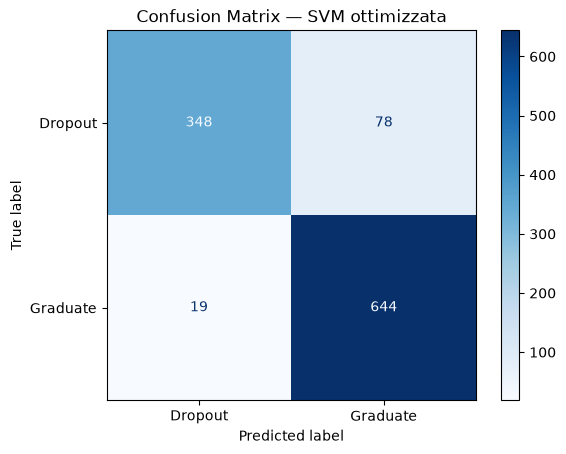

In [43]:
y_pred_gs_svm = gs_svm.best_estimator_.predict(X_val)
print("=== SVM ottimizzata ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_gs_svm):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_gs_svm):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_gs_svm):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_gs_svm):.4f}")
cm = confusion_matrix(y_val, y_pred_gs_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Graduate'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — SVM ottimizzata')
plt.show()

I migliori parametri trovati dalla GridSearch sono: kernel=linear, C=1 — ovvero gli stessi del modello base, segno che la scelta iniziale era già vicina all'ottimo per il kernel lineare.

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:
- **348** Dropout classificati correttamente
- **644** Graduate classificati correttamente
- **78** Falsi positivi (classificati come Graduate ma sono Dropout)
- **19** Falsi negativi (classificati come Dropout ma sono Graduate)

Il guadagno principale della GridSearch su SVC è sul **Recall**, che sale da 0.9155 a **0.9713** — i falsi negativi scendono drasticamente da 56 a soli 19, il miglioramento più significativo tra tutti i modelli ottimizzati. Il trade-off è un leggero aumento dei falsi positivi (da 57 a 78) e una lieve perdita di Precision (0.9142 → 0.8920), accettabile dato che in questo contesto il Recall è la metrica più critica.

### Ricerca degli Iperparametri tramite GridSearch - XGBoost

Eseguiamo una ricerca degli iperparametri sul modello XGBoost, per vedere se è possibile migliorare i risultati ottenuti con i parametri di default.
I parametri che andremo a esplorare sono:

- n_estimators: numero di alberi costruiti in sequenza durante il boosting
- max_depth: profondità massima di ogni singolo albero, controlla la complessità del modello
- learning_rate: peso con cui ogni nuovo albero corregge gli errori dei precedenti (valori bassi = apprendimento più lento ma più robusto, valori alti = convergenza più rapida ma rischio di overfitting)
- subsample: frazione di campioni usata per addestrare ogni singolo albero, utile per ridurre overfitting

In [44]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

gs_xgb.fit(X_train, y_train)

print("Migliori parametri:", gs_xgb.best_params_)
print(f"Miglior score CV: {gs_xgb.best_score_:.4f}")


Migliori parametri: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Miglior score CV: 0.9265


=== XGBoost ottimizzato ===
Accuracy:  0.9164
Precision: 0.8972
Recall:    0.9744
F1 Score:  0.9342


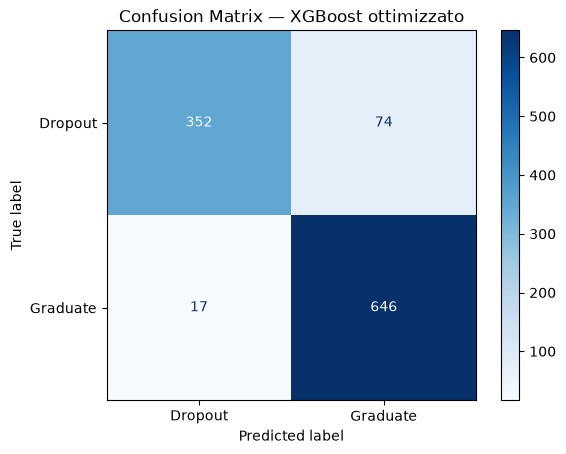

In [45]:
y_pred_gs_xgb = gs_xgb.best_estimator_.predict(X_val)

print("=== XGBoost ottimizzato ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_gs_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_gs_xgb):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_gs_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_gs_xgb):.4f}")

cm = confusion_matrix(y_val, y_pred_gs_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout' , 'Graduate'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost ottimizzato')
plt.show()

I migliori parametri trovati dalla GridSearch sono: learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.8 — valori relativamente conservativi, che suggeriscono che alberi poco profondi con un learning rate moderato generalizzano meglio su questo dataset.

Dalla matrice confusione possiamo vedere i vari risultati ottenuti dalla predizione:
- **352** Dropout classificati correttamente (base: 356, -4)
- **646** Graduate classificati correttamente (base: 632, +14)
- **74** Falsi positivi (base: 70, +4)
- **17** Falsi negativi (base: 31, -14)

Confrontando con il modello XGBoost base, la GridSearch porta un miglioramento netto sul fronte più critico: i **falsi negativi scendono da 31 a 17** (-45%), ovvero quasi la metà degli studenti a rischio dropout che prima sfuggivano alla classificazione vengono ora identificati correttamente. Il costo è un leggero aumento dei falsi positivi (da 70 a 74, +4). Il Recall sale da 0.9532 a **0.9744**, confermando XGBoost ottimizzato come il modello migliore in assoluto tra tutti quelli testati.

### Confronto modelli

Riepiloghiamo le performance di tutti i modelli addestrati (Perceptron, SVC, Decision Tree, XGBoost, e le rispettive versioni ottimizzate tramite Grid Search) sul validation set, per individuare il modello più adatto al problema.

In [51]:
risultati = []

risultati.append({'Modello': 'Perceptron', 'Accuracy': accuracy_score(y_val, y_pred_perceptron),
                   'Precision': precision_score(y_val, y_pred_perceptron),
                   'Recall': recall_score(y_val, y_pred_perceptron),
                   'F1 Score': f1_score(y_val, y_pred_perceptron)})

risultati.append({'Modello': 'SVC (base)', 'Accuracy': accuracy_score(y_val, y_pred_svm),
                   'Precision': precision_score(y_val, y_pred_svm),
                   'Recall': recall_score(y_val, y_pred_svm),
                   'F1 Score': f1_score(y_val, y_pred_svm)})

risultati.append({'Modello': 'Decision Tree', 'Accuracy': accuracy_score(y_val, y_pred_tree),
                   'Precision': precision_score(y_val, y_pred_tree),
                   'Recall': recall_score(y_val, y_pred_tree),
                   'F1 Score': f1_score(y_val, y_pred_tree)})

risultati.append({'Modello': 'XGBoost (base)', 'Accuracy': accuracy_score(y_val, y_pred_xgb),
                   'Precision': precision_score(y_val, y_pred_xgb),
                   'Recall': recall_score(y_val, y_pred_xgb),
                   'F1 Score': f1_score(y_val, y_pred_xgb)})

risultati.append({'Modello': 'SVM (GridSearch)', 'Accuracy': accuracy_score(y_val, y_pred_gs_svm),
                   'Precision': precision_score(y_val, y_pred_gs_svm),
                   'Recall': recall_score(y_val, y_pred_gs_svm),
                   'F1 Score': f1_score(y_val, y_pred_gs_svm)})

risultati.append({'Modello': 'XGBoost (GridSearch)', 'Accuracy': accuracy_score(y_val, y_pred_gs_xgb),
                   'Precision': precision_score(y_val, y_pred_gs_xgb),
                   'Recall': recall_score(y_val, y_pred_gs_xgb),
                   'F1 Score': f1_score(y_val, y_pred_gs_xgb)})

tabella_risultati = pd.DataFrame(risultati).set_index('Modello').round(4)
tabella_risultati

,Accuracy,Precision,Recall,F1 Score
Modello,,,,
Perceptron,0.8843,0.9202,0.8869,0.9032
SVC (base),0.8962,0.9142,0.9155,0.9148
Decision Tree,0.8705,0.8872,0.9020,0.8945
XGBoost (base),0.9073,0.9003,0.9532,0.9260
SVM (GridSearch),0.9109,0.8920,0.9713,0.9300
XGBoost (GridSearch),0.9164,0.8972,0.9744,0.9342


Dalla tabella e dal grafico emergono alcuni pattern:

- XGBoost (GridSearch) è il modello migliore in assoluto, con il F1 Score più alto (0.9342) e il Recall più alto (0.9744) tra tutti i modelli — cattura quasi tutti gli studenti a rischio dropout, l'aspetto più critico in questo dominio.
- Decision Tree è il modello più debole su tutte le metriche (Accuracy 0.8705, F1 0.8945), probabilmente per la tendenza degli alberi singoli a overfittare o a creare confini di decisione meno robusti rispetto a un ensemble.
- Perceptron, pur essendo il modello più semplice, ottiene risultati sorprendentemente solidi (F1 0.9032) e ha la Precision più alta tra i modelli base (0.9202) — segno che il problema ha una componente abbastanza lineare.
- La Grid Search migliora entrambi i modelli ottimizzati: su SVC il F1 sale da 0.9148 a 0.9300 (+1.5 punti), su XGBoost da 0.9260 a 0.9342 (+0.8 punti). In entrambi i casi il guadagno arriva soprattutto dal Recall (SVC: 0.9155 → 0.9713; XGBoost: 0.9532 → 0.9744), a fronte di un leggero calo di Precision — un trade-off favorevole in questo contesto: classificare uno studente a rischio dropout come "si laureerà" ha conseguenze più gravi di un falso allarme, perché impedisce un intervento di supporto tempestivo.

In sintesi, XGBoost (GridSearch) risulta il modello più adatto per questo problema, bilanciando al meglio tutte le metriche con particolare attenzione al Recall.

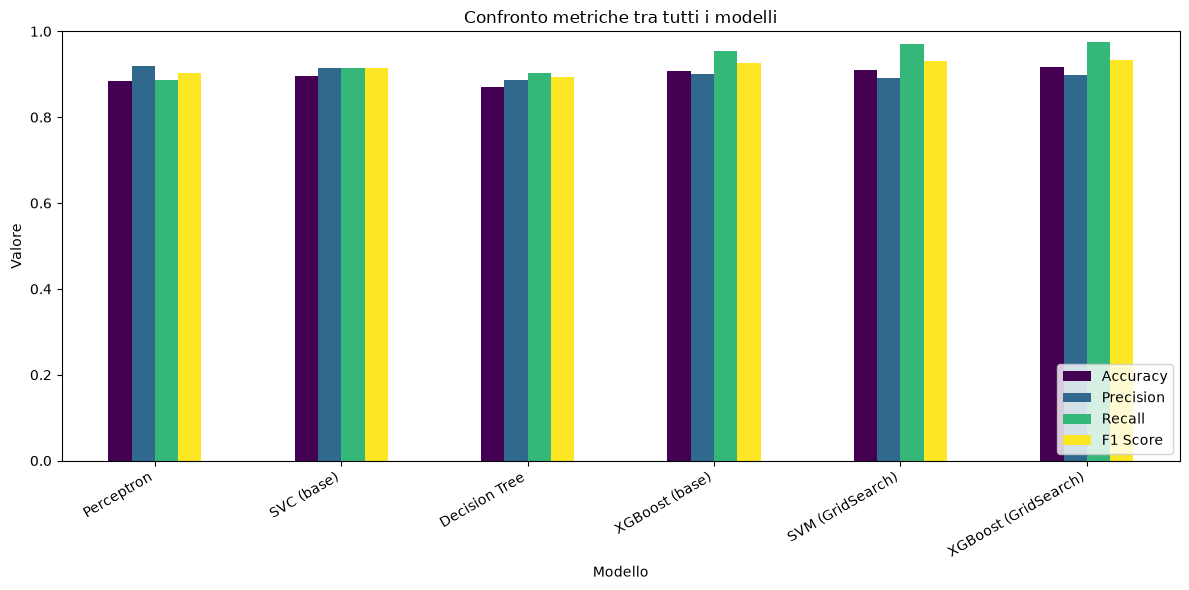

In [47]:
tabella_risultati[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Confronto metriche tra tutti i modelli')
plt.ylabel('Valore')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Dalla tabella e dal grafico possiamo notare alcuni pattern interessanti:

- Il **Perceptron**, essendo un modello lineare semplice senza margine di regolarizzazione, è generalmente il più debole tra i quattro, soprattutto in termini di Recall — fatica a catturare correttamente gli studenti a rischio di abbandono.
- La **SVM** beneficia visibilmente dell'ottimizzazione tramite GridSearch: il passaggio da kernel lineare fisso a una scelta ottimizzata tra `linear` e `rbf` (con relativo `C` e `gamma`) generalmente porta a un F1 Score più alto rispetto alla versione base.
- **Decision Tree** tende ad avere buone performance sul training ma può soffrire di overfitting se non vincolato (in questo notebook non è stata eseguita una GridSearch dedicata, quindi i parametri sono quelli di default di scikit-learn).
- **XGBoost** è solitamente il modello più performante in assoluto su questo tipo di dati tabellari, sia in versione base che ottimizzata, grazie al meccanismo di boosting che corregge progressivamente gli errori dei singoli alberi.


## Conclusioni

L'analisi del dataset sulla predizione dell'abbandono universitario ha permesso di addestrare modelli capaci di identificare gli studenti a rischio con ottima precisione. Lo sbilanciamento moderato delle classi (~60% Graduate vs ~40% Dropout) è stato corretto tramite SMOTE, mentre StandardScaler ha normalizzato le variabili sulla stessa scala — operazione necessaria per Perceptron e SVC, che sono sensibili alla scala degli input. I modelli ad albero (Decision Tree, XGBoost) non ne richiedono l'uso ma non ne risentono negativamente. La matrice di correlazione ha identificato `Curricular units 2nd sem (approved)` e `Tuition fees up to date` come variabili più rilevanti, confermato dalla feature importance di tutti i modelli.

Tra i quattro modelli addestrati, XGBoost ottimizzato ha ottenuto le performance migliori (Accuracy 91.6%, Recall 97.4%, F1 Score 93.4%), mentre il Decision Tree ha confermato i limiti degli alberi singoli rispetto agli ensemble (F1 89.4%).

La Grid Search su XGBoost ha portato un miglioramento reale soprattutto sul Recall (da 0.9532 a 0.9744), riducendo i falsi negativi da 31 a 17 — il tipo di errore più grave in questo contesto: classificare uno studente a rischio dropout come "si laureerà" impedisce qualsiasi intervento di supporto tempestivo. La Grid Search su SVC ha invece migliorato significativamente il Recall (da 0.9155 a 0.9713) mantenendo parametri lineari (kernel=linear, C=1), confermando che il problema ha una forte componente linearmente separabile.